# LGBTQ+ Distributions

Renders a horizontal frequency bar chart of total mentions per lgbtq+ bucket, styled like `demographic_bias/lgbtq_bias.svg`. Uses the **same `groups` mapping as `conclusions/get_conclusions.ipynb`** and the same `Conclusions`-column parsing as `lgbtq_conclusions.ipynb`. Saves to `lgbtq_distributions.png` and `lgbtq_distributions.svg`.

In [1]:
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

_IMGS = Path.cwd() / "imgs"
_IMGS.mkdir(parents=True, exist_ok=True)
_REPO = _IMGS.parents[2]  # .../viz

In [2]:
df = pd.read_csv(_REPO / "data" / "papers.csv")

paper_conclusions_lst = df["Conclusions"].tolist()
conclusions_mps: dict[str, dict[str, int]] = {}

for paper in paper_conclusions_lst:
    if isinstance(paper, float):
        continue

    for conclusion in str(paper).split(","):
        try:
            value = re.sub(r"\s*\([^)]*\)", "", conclusion).strip()
            key, val = (part.strip() for part in value.split(":", 1))
            if not key or not val:
                continue

            key_norm = key.strip()
            yn = val.strip().lower().split(None, 1)[0]

            if key_norm not in conclusions_mps:
                conclusions_mps[key_norm] = {"yes": 0, "no": 0}

            if yn == "yes":
                conclusions_mps[key_norm]["yes"] += 1
            elif yn == "no":
                conclusions_mps[key_norm]["no"] += 1
        except ValueError:
            continue

len(conclusions_mps)

204

In [3]:
groups = {
    "Gay or Lesbian": ["gay/lesbian", 'Homosexual', 'Gay or Lesbian'],
    "Heterosexual": ['heterosexual', 'Heterosexual'],
    "Transgender": ['Transgender man', 'Transgender woman',
                    'Transgender', 'Transgender Female', 'Transgender Male'],
    "Bisexual": ['bisexual', 'Bisexual'],
}

lgbtq_totals: dict[str, int] = {}
for new_name, categories in groups.items():
    yes_total = sum(conclusions_mps.get(cat, {"yes": 0})["yes"] for cat in categories)
    no_total = sum(conclusions_mps.get(cat, {"no": 0})["no"] for cat in categories)
    lgbtq_totals[new_name] = yes_total + no_total

lgbtq_totals

{'Gay or Lesbian': 3, 'Heterosexual': 3, 'Transgender': 7, 'Bisexual': 3}

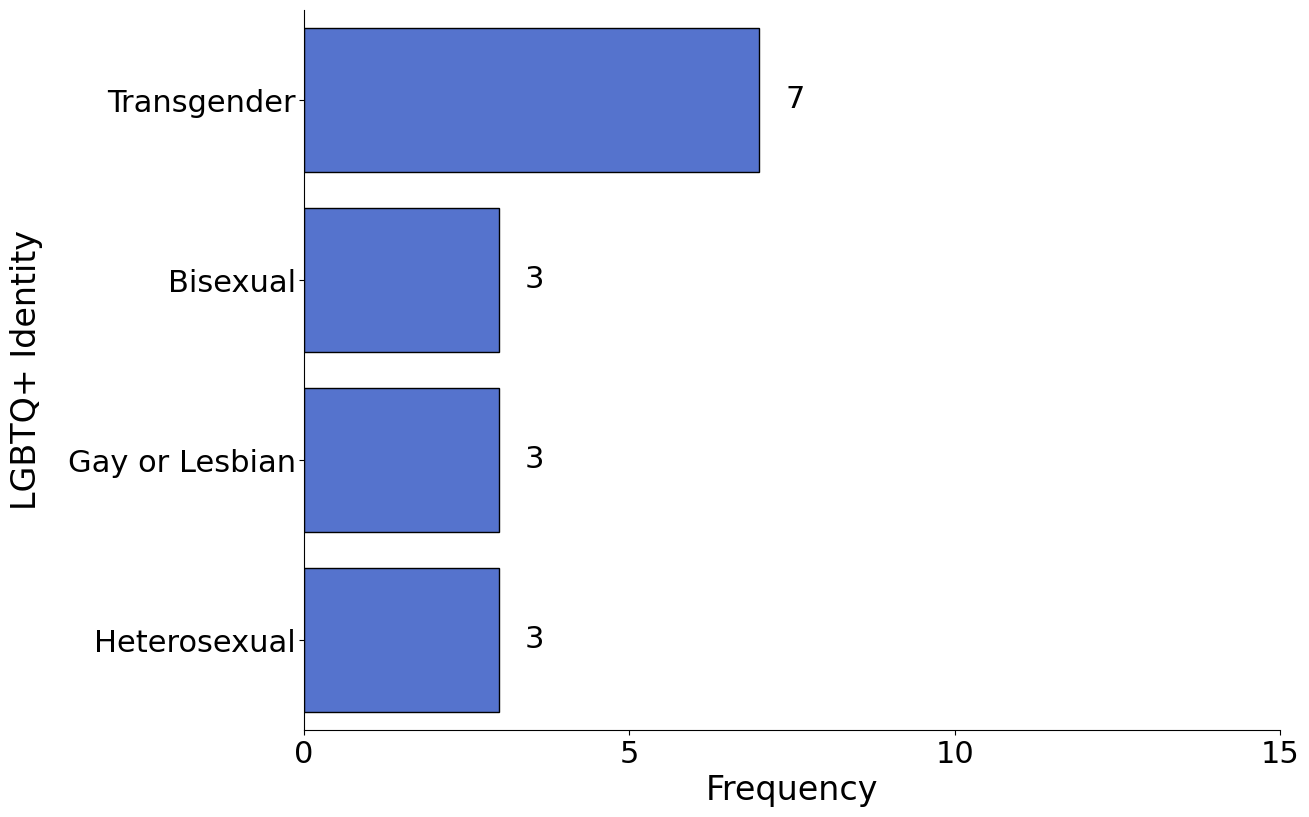

Wrote /Users/josh/Desktop/harvard/kempner/viz/conclusions/lgbtq_conclusions/v3/lgbtq_distributions.png
Wrote /Users/josh/Desktop/harvard/kempner/viz/conclusions/lgbtq_conclusions/v3/lgbtq_distributions.svg


In [4]:
freq_pairs = sorted(lgbtq_totals.items(), key=lambda kv: (-kv[1], kv[0]))
plot_df = pd.DataFrame(freq_pairs, columns=["group", "count"])

x_tick_labelsize = 22
axis_title_fontsize = 24
count_label_pad = 0.4
count_label_fontsize = 22

n_cats = len(plot_df)
fig, ax = plt.subplots(figsize=(12, max(8, 0.38 * n_cats)))

sns.barplot(
    data=plot_df,
    y="group",
    x="count",
    ax=ax,
    color="royalblue",
    edgecolor="black",
    linewidth=1,
    order=plot_df["group"],
)
sns.despine(ax=ax)

counts = plot_df["count"].tolist()
xmax_plot = int(math.ceil(max(counts) / 5.0)) * 5 + 5 if counts else 10
x_step = 10 if xmax_plot >= 40 else 5

for i, count in enumerate(counts):
    ax.text(
        count + count_label_pad,
        i,
        f"{count}",
        ha="left",
        va="center",
        fontsize=count_label_fontsize,
    )

ax.set_xlim(0, xmax_plot)
ax.set_xticks(range(0, xmax_plot + 1, x_step))

ax.set_xlabel("Frequency", fontsize=axis_title_fontsize)
ax.set_ylabel("LGBTQ+ Identity", fontsize=axis_title_fontsize, labelpad=18)

ax.tick_params(axis="x", labelsize=x_tick_labelsize)
ax.tick_params(axis="y", labelsize=x_tick_labelsize, pad=2)
plt.setp(ax.get_yticklabels(), rotation=0, ha="right")

longest = max((len(str(t.get_text())) for t in ax.get_yticklabels()), default=10)
fig.subplots_adjust(
    left=min(0.38, max(0.11, 0.085 + 0.0058 * longest)),
    right=0.98,
    top=0.98,
    bottom=0.08,
)

png_path = _IMGS / "lgbtq_distributions.png"
svg_path = _IMGS / "lgbtq_distributions.svg"
fig.savefig(svg_path, format="svg", bbox_inches="tight")
fig.savefig(png_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Wrote {png_path}")
print(f"Wrote {svg_path}")